# DiCE tests for "blood pressure" data and models

In [3]:
from aiwhatif_cf.config import SystemConfig, RandomExplainerProfile

system_config = SystemConfig(
    target="hltprhb",
)
explainer_profile = RandomExplainerProfile()

print(system_config)

=== System Config ===
target                 : hltprhb
feature_cols           : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'gndr', 'dosprt']
immutable_cols         : ['gndr']
continuous_features    : ['bmi']
backend                : sklearn
model_type             : classifier
target_factor          : 0.5


In [4]:
print(explainer_profile)

=== Random Explainer Profile ===
method                 : random
total_CFs              : 3
desired_class          : 0
stopping_threshold     : 0.5
posthoc_sparsity_param : 0.1
posthoc_sparsity_algorithm: linear
permitted_range        : None
features_to_vary       : None
random_seed            : 42


In [5]:
from aiwhatif_cf.config import TRAIN_DATA_PATH, TEST_DATA_PATH, MODEL_PATH_HB, CF_OUTPUTS

# extracts paths (varies from notebooks)
TARGET          = system_config.target
MODEL_PATH      = MODEL_PATH_HB
CF_OUTPUTS_DIR  = CF_OUTPUTS

print(TRAIN_DATA_PATH.is_file())
print(TEST_DATA_PATH.is_file())
print(MODEL_PATH.is_file())


True
True
True


# loading data

In [6]:
import pandas as pd

train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

In [7]:
train_df.head()

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhb
0,2.0,1.0,2.0,3.0,1.0,0,26.061679,1,2.0,0
1,3.0,4.0,6.0,2.0,2.0,0,30.864198,1,7.0,0
2,3.0,4.0,6.0,7.0,1.0,0,22.857143,1,7.0,0
3,2.0,3.0,6.0,6.0,2.0,0,26.672763,2,7.0,1
4,4.0,3.0,1.0,7.0,3.0,0,27.757487,1,4.0,0


In [8]:
train_df.describe()

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhb
count,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000
mean,3.223064,3.152754,4.351854,4.623331,1.771949,0.045464,25.919027,1.527294,3.160843,0.214092
std,1.308793,1.110134,1.830636,2.043209,0.829678,0.208323,4.149568,0.499262,2.597858,0.410197
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,16.003658,1.000000,0.000000,0.000000
25%,2.000000,2.000000,3.000000,3.000000,1.000000,0.000000,22.913033,1.000000,0.000000,0.000000
50%,3.000000,3.000000,5.000000,5.000000,2.000000,0.000000,25.535446,2.000000,3.000000,0.000000
75%,4.000000,4.000000,6.000000,7.000000,2.000000,0.000000,28.373702,2.000000,5.000000,0.000000
max,7.000000,7.000000,6.000000,7.000000,4.000000,1.000000,40.000000,2.000000,7.000000,1.000000


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32883 entries, 0 to 32882
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   etfruit   32883 non-null  float64
 1   eatveg    32883 non-null  float64
 2   cgtsmok   32883 non-null  float64
 3   alcfreq   32883 non-null  float64
 4   slprl     32883 non-null  float64
 5   paccnois  32883 non-null  int64  
 6   bmi       32883 non-null  float64
 7   gndr      32883 non-null  int64  
 8   dosprt    32883 non-null  float64
 9   hltprhb   32883 non-null  int64  
dtypes: float64(7), int64(3)
memory usage: 2.5 MB


### checking class distribution of datasets

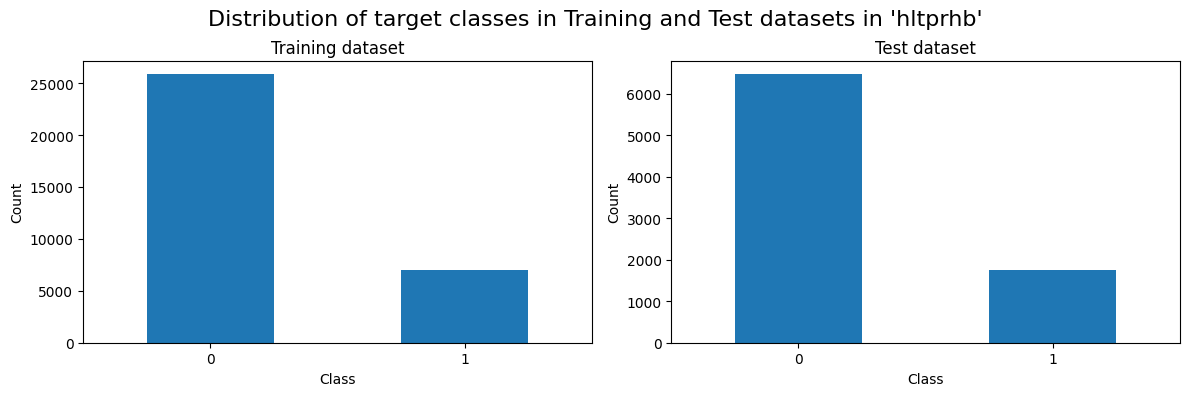

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
datasets = [("Training", train_df), ("Test", test_df)]

for ax, (name, df) in zip(axes, datasets):
    df[TARGET].value_counts().plot(kind="bar", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(f"{name} dataset")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

fig.suptitle(f"Distribution of target classes in Training and Test datasets in '{TARGET}'", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


# load and inspect predictor model

that the models features and importances seem to match what the later 
counterfactual models recommend.

In [ ]:
import joblib

rf_model = joblib.load(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

model_features = rf_model.feature_names_in_

print("feature names in model: ", model_features)
print("data features == model features: ", system_config.feature_cols == model_features)
print("Immutable: ", system_config.immutable_cols)

Loaded model: /home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/models/rf_hltprhb_2026-03-31.pkl
feature names in model:  ['etfruit' 'eatveg' 'cgtsmok' 'alcfreq' 'slprl' 'paccnois' 'bmi' 'gndr'
 'dosprt']
data features == model features:  [ True  True  True  True  True  True  True  True  True]
Immutable:  ['gndr']
features_to_vary:  ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']


In [12]:
X_test = test_df[system_config.feature_cols]
y_true = test_df[system_config.target]

y_pred = rf_model.predict(X_test)

In [13]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay


print(classification_report(y_true, y_pred))
print()
print("Roc Score auc score: ", roc_auc_score(y_true, y_pred), "\n")

              precision    recall  f1-score   support

           0       0.80      0.98      0.88      6461
           1       0.54      0.08      0.14      1760

    accuracy                           0.79      8221
   macro avg       0.67      0.53      0.51      8221
weighted avg       0.74      0.79      0.72      8221


Roc Score auc score:  0.5321653258713117 



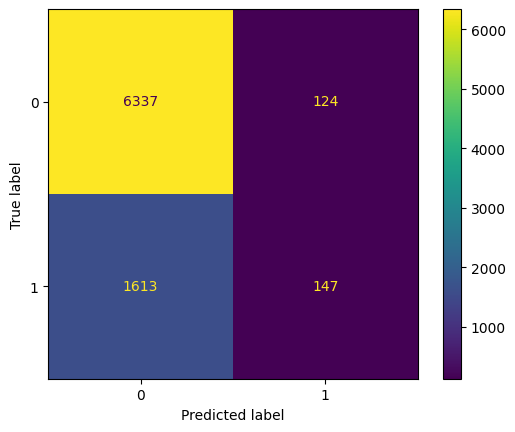

In [14]:
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

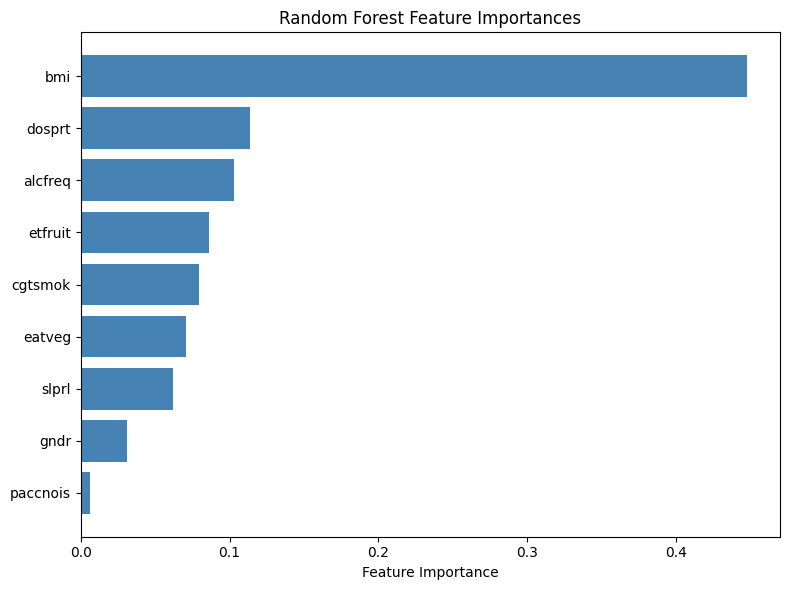

In [15]:
import numpy as np

importances = rf_model.feature_importances_

idx = np.argsort(importances)
sorted_features = model_features[idx]
sorted_importances = importances[idx]

plt.figure(figsize=(8, 6))
plt.barh(sorted_features, sorted_importances, color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


# Create the DiCE-objects with test data

In [19]:
import dice_ml

dice_data = dice_ml.Data(
    dataframe=test_df,
    continuous_features=system_config.continuous_features, # bmi
    outcome_name=TARGET
)

dice_model = dice_ml.Model(
    model=rf_model,
    backend=system_config.backend,         # sklearn
    model_type=system_config.model_type,   # classifier
)

# integrate data and dice model into explainer
# random method = standard?
explainer = dice_ml.Dice(
    dice_data,
    dice_model,
    method=explainer_profile.method, # random
)

# Select datapoints to test and generate CF

In [16]:
positives = test_df[test_df[TARGET] == 1]
positives.head(20)

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhb
0,3.0,3.0,6.0,7.0,1.0,0,29.384757,2,0.0,1
8,3.0,2.0,4.0,6.0,2.0,0,30.062102,2,7.0,1
10,4.0,3.0,1.0,2.0,2.0,0,27.173102,1,3.0,1
12,4.0,3.0,1.0,7.0,2.0,0,26.122449,1,0.0,1
14,1.0,1.0,4.0,3.0,3.0,0,26.827421,2,7.0,1
17,7.0,2.0,1.0,3.0,4.0,0,21.453574,2,5.0,1
18,3.0,3.0,6.0,6.0,2.0,1,31.229454,2,0.0,1
21,4.0,4.0,6.0,7.0,2.0,0,21.777553,1,5.0,1
24,1.0,1.0,6.0,6.0,2.0,0,29.296875,2,0.0,1
28,3.0,2.0,4.0,7.0,1.0,0,20.675803,1,7.0,1


Selected indexes to test: 
- [4]  normal BMI, middle high values
- [24] extremely high BMI (39.25)
- [32] high slprl (4), high dosprt(5)
- [45] low cgtsmok (1), low slpti (1)
- [86] very high BMI (37.87), high slpri(4)

In [ ]:
selected_indices = [4, 24, 32, 45, 86]

query_instances = test_df.loc[selected_indices][system_config.feature_cols]
query_instances

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt
4,2.0,2.0,6.0,7.0,1.0,0,29.320988,1,3.0
24,1.0,1.0,6.0,6.0,2.0,0,29.296875,2,0.0
32,4.0,4.0,1.0,7.0,1.0,0,26.234568,1,3.0
45,2.0,2.0,4.0,3.0,2.0,1,25.648918,2,5.0
86,4.0,3.0,4.0,1.0,1.0,1,24.031709,1,5.0


In [ ]:
print(system_config.features_to_vary)

['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


cf_result = explainer.generate_counterfactuals(
        query_instances=query_instances, # could be multiple!
        total_CFs=3,
        desired_class=0,      # or opposite?

        desired_range=None,   # for regression problems
        permitted_range=None, # dict with feat_names as keys, and p-range as list

        features_to_vary=system_config.features_to_vary,
        stopping_threshold=0.5,         # config.stopping_threshold, # 0.5

        #### weights and post-hoc config - random model does not accept proximity etc...
        # proximity_weight=None,        # pos float: Larger this weight, more close the counterfactuals are to the query_instance. Used by ['genetic', 'gradientdescent'],
        # sparsity_weight=None,         # pos float: Larger this weight, less features are changed from the query_instance. IGNORED by random
        # diversity_weight=None,        # pos float: Larger this weight, more diverse the counterfactuals are.  IGNORED by random
        # categorical_penalty=None,     # pos float: A weight to ensure that all levels of a categorical variable sums to 1. IGNORED by random
        # sample_size

        posthoc_sparsity_param=0.1,     # Parameter for the post-hoc operation on continuous features to enhance sparsity.
        posthoc_sparsity_algorithm="linear", # Perform either linear or binary search.

        # other
        verbose=True,
        random_seed=101
)


 20%|██        | 1/5 [00:00<00:01,  2.32it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


 40%|████      | 2/5 [00:00<00:01,  2.29it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


 60%|██████    | 3/5 [00:01<00:00,  2.31it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


 80%|████████  | 4/5 [00:01<00:00,  2.30it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


100%|██████████| 5/5 [00:02<00:00,  2.31it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


# Annoting CF with risk:

In [20]:
cf_result.cf_examples_list

In [21]:
print(dir(cf_result.cf_examples_list[0]))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_dump_output', '_visualize_internal', 'data_interface', 'desired_class', 'desired_range', 'display_df', 'final_cfs_df', 'final_cfs_df_sparse', 'final_cfs_list', 'from_json', 'model_type', 'new_outcome', 'posthoc_sparsity_param', 'print_list', 'test_instance_df', 'test_pred', 'to_json', 'visualize_as_dataframe', 'visualize_as_list']


In [22]:
query_instances


,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt
4,2.0,2.0,6.0,7.0,1.0,0,29.320988,1,3.0
24,1.0,1.0,6.0,6.0,2.0,0,29.296875,2,0.0
32,4.0,4.0,1.0,7.0,1.0,0,26.234568,1,3.0
45,2.0,2.0,4.0,3.0,2.0,1,25.648918,2,5.0
86,4.0,3.0,4.0,1.0,1.0,1,24.031709,1,5.0


In [23]:
cf_df = cf_result.cf_examples_list[0].final_cfs_df.copy()
cf_df

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhb
0,2.0,2.0,6.0,7.0,1.0,0,19.827835,1,3.0,0
1,3.0,2.0,6.0,7.0,1.0,0,29.320988,1,3.0,0
2,2.0,2.0,6.0,2.0,1.0,0,21.532943,1,3.0,0


In [ ]:
from aiwhatif_cf.dice_pipeline.risk import RiskEvaluator

risk_evaluator = RiskEvaluator(
    model=rf_model,   # for now, sklearn classifer models...
    feature_cols=system_config.feature_cols,
    target_factor=system_config.target_factor, # 0.5
)


In [25]:
query_instance = query_instances.loc[[4]]

cf_risk_annoted = risk_evaluator.annotate(
    query_original=query_instance,
    counterfactuals=cf_df,
)

cf_risk_annoted

,query_index,cf_id,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhb,original_risk,target_risk,predicted_risk,meets_target_risk
0,4,cf_0,2.0,2.0,6.0,7.0,1.0,0,19.827835,1,3.0,0,0.16867,0.084335,0.052284,True
1,4,cf_1,3.0,2.0,6.0,7.0,1.0,0,29.320988,1,3.0,0,0.16867,0.084335,0.159419,False
2,4,cf_2,2.0,2.0,6.0,2.0,1.0,0,21.532943,1,3.0,0,0.16867,0.084335,0.043955,True


In [ ]:
from aiwhatif_cf.dice_pipeline.recommendations import DiceRecommender

recommender = DiceRecommender(
    feature_cols=system_config.feature_cols,
    target=TARGET,
    data_filename=TEST_DATA_PATH.name,
)

recommendations = recommender.get_recommendations(
    original=query_instance,
    annoted_counterfactuals=cf_risk_annoted,
)

recommendations

[{'query_index': 4,
  'cf_id': 'cf_0',
  'original_risk': 0.1686698147023617,
  'target_risk': 0.08433490735118085,
  'predicted_risk': 0.05228416547626558,
  'meets_target_risk': True,
  'changes': [('bmi', 29.320987654320987, 19.827835)]},
 {'query_index': 4,
  'cf_id': 'cf_1',
  'original_risk': 0.1686698147023617,
  'target_risk': 0.08433490735118085,
  'predicted_risk': 0.15941939177043635,
  'meets_target_risk': False,
  'changes': [('etfruit', 2.0, 3.0)]},
 {'query_index': 4,
  'cf_id': 'cf_2',
  'original_risk': 0.1686698147023617,
  'target_risk': 0.08433490735118085,
  'predicted_risk': 0.04395481490569186,
  'meets_target_risk': True,
  'changes': [('alcfreq', 7.0, 2.0), ('bmi', 29.320987654320987, 21.532943)]}]

In [27]:
# FIX - immutable features - not to be shown in original query

formatted_rec = recommender.format_recommendations(
    query_instance,
    recommendations,
    true_outcome = test_df.loc[query_instance.index, TARGET]
)

print(formatted_rec)

Task / Target: hltprhb
Data filename: ess_ready_v2_hltprhb_test.csv
Selected query instance (index 4):

 etfruit  eatveg  cgtsmok  alcfreq  slprl  paccnois       bmi  gndr  dosprt
     2.0     2.0      6.0      7.0    1.0         0 29.320988     1     3.0

Original predicted risk (P(hltprhb=4    0
Name: hltprhb, dtype: int64)): 0.1687
Target-risk threshold: 0.0843

=== Changes per Counterfactual (vs Original) ===

--- cf_0 ---
Predicted risk: 0.0523
Meets target:   True
Changes:
  - bmi: 29.321 → 19.828

--- cf_1 ---
Predicted risk: 0.1594
Meets target:   False
Changes:
  - etfruit: 2.000 → 3.000

--- cf_2 ---
Predicted risk: 0.0440
Meets target:   True
Changes:
  - alcfreq: 7.000 → 2.000
  - bmi: 29.321 → 21.533



### Batch annotation

In [28]:
rows = []

for i, (idx, original_row) in enumerate(zip(selected_indices, query_instances.to_dict("records"))):

    # Convert original row to DataFrame
    original_df = pd.DataFrame([original_row])

    # Extract CFs for this instance
    cf_df = cf_result.cf_examples_list[i].final_cfs_df.copy()

    # Annotate CFs with risk information
    cf_risk = risk_evaluator.annotate(original_df, cf_df)

    # Extract original + target risk (same for all CFs)
    original_risk = cf_risk["original_risk"].iloc[0]
    target_risk = cf_risk["target_risk"].iloc[0]

    # Extract outcome value for original instance
    outcome_col = TARGET
    outcome_value = test_df.loc[idx, TARGET]

    # --- ORIGINAL ROW ---
    # Create a full row with the same columns as CF rows
    orig_row = {col: None for col in cf_risk.columns}

    # Insert feature values
    for col, val in original_row.items():
        orig_row[col] = val

    # Insert metadata
    orig_row["query_index"] = idx
    orig_row["cf_id"] = "original"

    # Insert correct risk values
    orig_row["original_risk"] = original_risk
    orig_row["target_risk"] = target_risk

    # Insert outcome
    orig_row[outcome_col] = outcome_value

    rows.append(orig_row)

    # --- CF ROWS ---
    for j, row in cf_risk.iterrows():
        cf_row = row.to_dict()
        cf_row["query_index"] = idx
        cf_row["cf_id"] = f"cf_{j+1}"
        rows.append(cf_row)

# Build final DataFrame
annotated_batch = pd.DataFrame(rows)

# Move query_index and cf_id first
first_cols = ["query_index", "cf_id"]
other_cols = [c for c in annotated_batch.columns if c not in first_cols]
annotated_batch = annotated_batch[first_cols + other_cols]


In [29]:
annotated_batch

,query_index,cf_id,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhb,original_risk,target_risk,predicted_risk,meets_target_risk
0,4,original,2.0,2.0,6.0,7.0,1.0,0,29.320988,1,3.0,0,0.168670,0.084335,NaN,None
1,4,cf_1,2.0,2.0,6.0,7.0,1.0,0,19.827835,1,3.0,0,0.168670,0.084335,0.052284,True
2,4,cf_2,3.0,2.0,6.0,7.0,1.0,0,29.320988,1,3.0,0,0.168670,0.084335,0.159419,False
3,4,cf_3,2.0,2.0,6.0,2.0,1.0,0,21.532943,1,3.0,0,0.168670,0.084335,0.043955,True
4,24,original,1.0,1.0,6.0,6.0,2.0,0,29.296875,2,0.0,1,0.527647,0.263823,NaN,None
5,24,cf_1,1.0,1.0,6.0,2.0,2.0,0,29.296875,2,1.0,0,0.527647,0.263823,0.286490,False
6,24,cf_2,1.0,1.0,6.0,6.0,2.0,0,24.708138,2,5.0,0,0.527647,0.263823,0.171292,True
7,24,cf_3,1.0,6.0,6.0,6.0,2.0,0,29.296875,2,1.0,0,0.527647,0.263823,0.321241,False
8,32,original,4.0,4.0,1.0,7.0,1.0,0,26.234568,1,3.0,0,0.074322,0.037161,NaN,None
9,32,cf_1,4.0,4.0,1.0,7.0,1.0,0,19.827835,1,3.0,0,0.074322,0.037161,0.029672,True


In [30]:
all_recommendations = []

for idx in selected_indices:
    # 1. Extract original instance
    query_instance = query_instances.loc[[idx]]

    # 2. Extract CFs for this instance
    cf_df = cf_result.cf_examples_list[selected_indices.index(idx)].final_cfs_df.copy()

    # 3. Annotate CF risks
    cf_risk_annoted = risk_evaluator.annotate(query_instance, cf_df)

    # 4. Generate recommendations
    recs = recommender.get_recommendations(
        original=query_instance,
        annoted_counterfactuals=cf_risk_annoted,
    )

    # 5. Store everything for export
    all_recommendations.append({
        "query_index": idx,
        "cf_recs": recs
    })

In [ ]:
import datetime as dt
from sklearn.metrics import classification_report

# --- Prepare output directory ---
today = dt.datetime.today().strftime("%Y-%m-%d")
output_dir = CF_OUTPUTS_DIR / f"DiCE_{today}_{TARGET}"
output_dir.mkdir(parents=True, exist_ok=True)

# --- Save train and test data and annotated CF batch ---
train_df.to_csv(output_dir / TRAIN_DATA_PATH.name, index=False)
test_df.to_csv(output_dir / TEST_DATA_PATH.name, index=False)
annotated_batch.to_csv(output_dir / f"DiCE_annotated_{TARGET}.csv", index=False)

# --- Save config  ---
config_path = output_dir / f"DiCE_config_{TARGET}.txt"
with open(config_path, "w", encoding="utf-8") as f:
    f.write("=== CONFIGURATION ===\n\n")
    f.write(str(system_config))   # relies on __str__()
    f.write("\n\n")

# --- Save recommendations ---
rec_path = output_dir / f"DiCE_recommendations_{TARGET}.txt"
with open(rec_path, "w", encoding="utf-8") as f:
    f.write("=== RECOMMENDATIONS ===\n\n")

    for rec in all_recommendations:
        qidx = rec["query_index"]
        true_y = test_df.loc[qidx, TARGET]

        formatted = recommender.format_recommendations(
            query_instance=query_instances.loc[[qidx]],
            recs=rec["cf_recs"],
            true_outcome=true_y
        )
        f.write(formatted)
        f.write("\n\n" + "="*80 + "\n\n")

# --- Save model parameters + performance ---
rf_info_path = output_dir / f"rf_{TARGET}_info.txt"

# Compute predictions on test set
report = classification_report(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

with open(rf_info_path, "w", encoding="utf-8") as f:
    f.write("=== RANDOM FOREST MODEL PATH ===\n")
    f.write(f"{system_config.model_path}\n\n")

    f.write("=== RANDOM FOREST PARAMETERS ===\n\n")
    for k, v in rf_model.get_params().items():
        f.write(f"{k}: {v}\n")

    f.write("\n\n=== MODEL PERFORMANCE (TEST SET) ===\n\n")
    f.write(report)
    f.write(f"\nRoc Auc Score: {roc_auc}")



In [ ]:
from aiwhatif_cf.dice_pipeline.visualizations import make_cf_heatmaps

for idx in selected_indices:
    query_row = query_instances.loc[[idx]]
    cf_df = cf_result.cf_examples_list[
        selected_indices.index(idx)
    ].final_cfs_df.copy()

    make_cf_heatmaps(
        query_df=query_row,
        cf_df=cf_df,
        feature_cols=system_config.feature_cols,
        out_dir=output_dir / "cf_heatmaps",
        prefix=f"cf_{idx}",
        normalize=True
    )
